In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys
import platform

libraries = [
    "python",
    "numpy",
    "pandas",
    "scikit-learn",
    "tensorflow",
    "keras",
    "streamlit",
    "matplotlib",
    "joblib"
]

print("🔹 SYSTEM INFORMATION")
print("-------------------")
print(f"Python Version     : {sys.version}")
print(f"Platform           : {platform.system()} {platform.release()}")
print("\n🔹 LIBRARY VERSIONS")
print("-------------------")

for lib in libraries[1:]:
    try:
        module = __import__(lib.replace("-", "_"))
        print(f"{lib:<15}: {module.__version__}")
    except Exception as e:
        print(f"{lib:<15}: Not Installed")


🔹 SYSTEM INFORMATION
-------------------
Python Version     : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform           : Linux 6.6.122+

🔹 LIBRARY VERSIONS
-------------------
numpy          : 2.0.2
pandas         : 2.2.2
scikit-learn   : Not Installed
tensorflow     : 2.20.0
keras          : 3.13.2
streamlit      : Not Installed
matplotlib     : 3.10.0
joblib         : 1.5.3


## **1.Knowing our Dataset**

In [4]:
df=pd.read_csv("/content/drive/MyDrive/Tesla_Project/TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [5]:
df.shape

(2416, 7)

In [6]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [8]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


# **2.EDA**

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


(array([724.,  96., 393., 659., 374., 143.,  10.,   8.,   6.,   3.]),
 array([ 16.139999 ,  81.8949993, 147.6499996, 213.4049999, 279.1600002,
        344.9150005, 410.6700008, 476.4250011, 542.1800014, 607.9350017,
        673.690002 ]),
 <BarContainer object of 10 artists>)

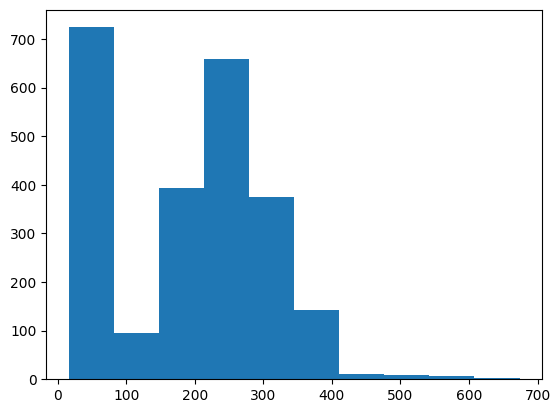

In [12]:
plt.hist(df['Open'])                                               #Price at which Tesla stock opened when the market started that day.

/tmp/ipykernel_3103/858187559.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Open'])


<Axes: xlabel='Open', ylabel='Density'>

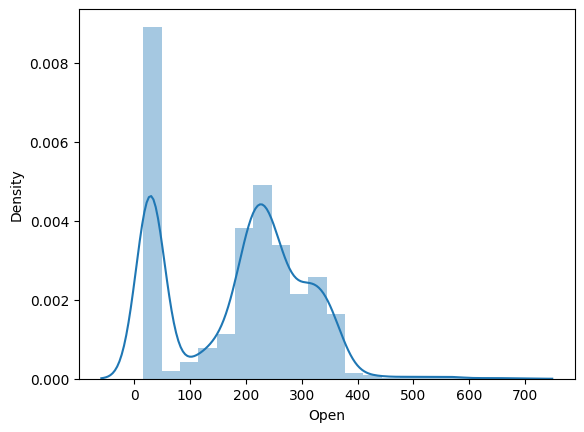

In [13]:
sns.distplot(df['Open'])

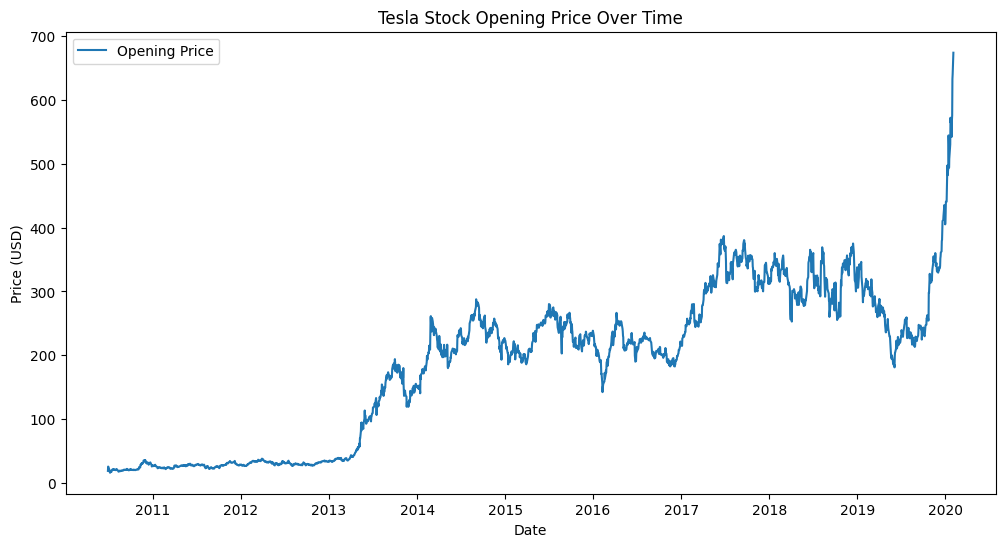

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df['Open'], label='Opening Price')
plt.title("Tesla Stock Opening Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

<Axes: ylabel='Open'>

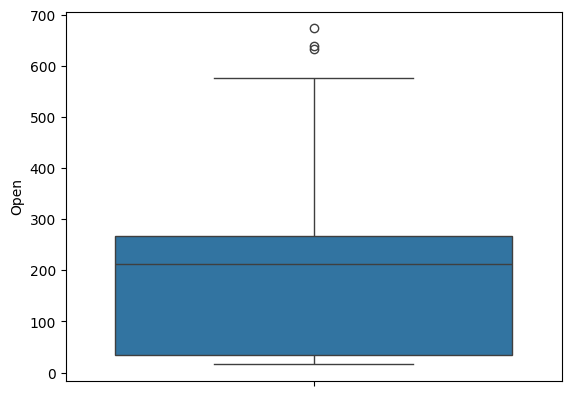

In [15]:
sns.boxplot(df['Open'])

In [16]:
df.sample(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-09-07,260.100006,268.350006,252.250000,263.239990,263.239990,22491900
2011-08-03,27.500000,27.830000,26.340000,27.200001,27.200001,1794500
2012-06-06,28.200001,29.450001,28.139999,29.219999,29.219999,909900
2017-07-07,313.500000,317.000000,307.380005,313.220001,313.220001,14176900
2015-07-10,262.220001,263.000000,257.820007,259.149994,259.149994,2610900
2015-04-02,190.229996,193.229996,190.000000,191.000000,191.000000,5010400
2016-07-06,210.000000,215.229996,209.000000,214.440002,214.440002,4919900
2019-03-06,276.480011,281.510010,274.390015,276.239990,276.239990,10335500
2014-05-02,208.600006,211.360001,206.520004,210.910004,210.910004,4086800


(array([728., 138., 710., 522., 288.,  12.,   9.,   6.,   2.,   1.]),
 array([ 16.629999 ,  93.5810006, 170.5320022, 247.4830038, 324.4340054,
        401.385007 , 478.3360086, 555.2870102, 632.2380118, 709.1890134,
        786.140015 ]),
 <BarContainer object of 10 artists>)

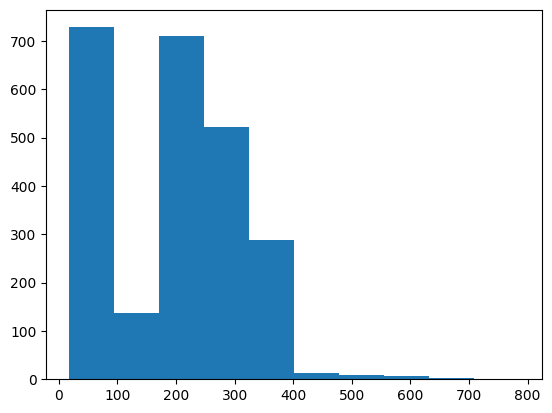

In [17]:
plt.hist(df['High'])

/tmp/ipykernel_3103/2504026347.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['High'])


<Axes: xlabel='High', ylabel='Density'>

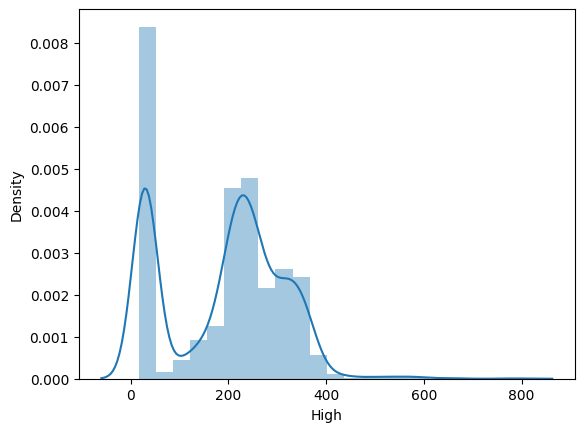

In [18]:
sns.distplot(df['High'])

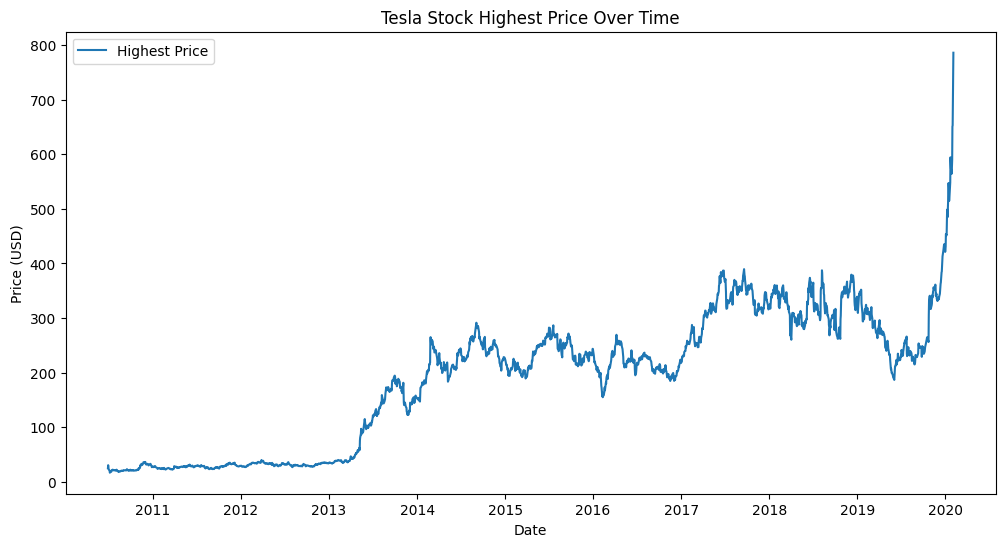

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df['High'], label='Highest Price')
plt.title("Tesla Stock Highest Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

<Axes: ylabel='High'>

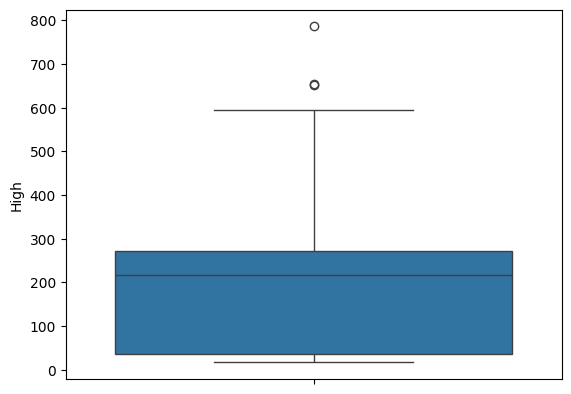

In [20]:
sns.boxplot(df['High'])

(array([724., 108., 417., 640., 396., 106.,  10.,   7.,   5.,   3.]),
 array([ 14.98    ,  80.834002, 146.688004, 212.542006, 278.396008,
        344.25001 , 410.104012, 475.958014, 541.812016, 607.666018,
        673.52002 ]),
 <BarContainer object of 10 artists>)

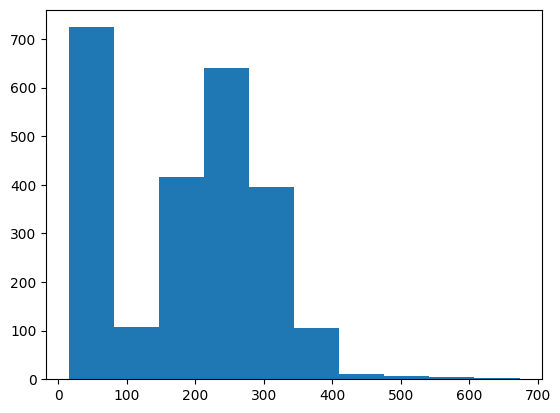

In [21]:
plt.hist(df['Low'])

/tmp/ipykernel_3103/3839789356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Low'])


<Axes: xlabel='Low', ylabel='Density'>

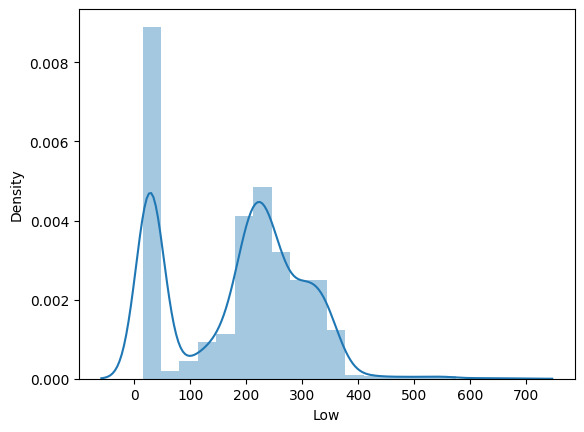

In [22]:
sns.distplot(df['Low'])

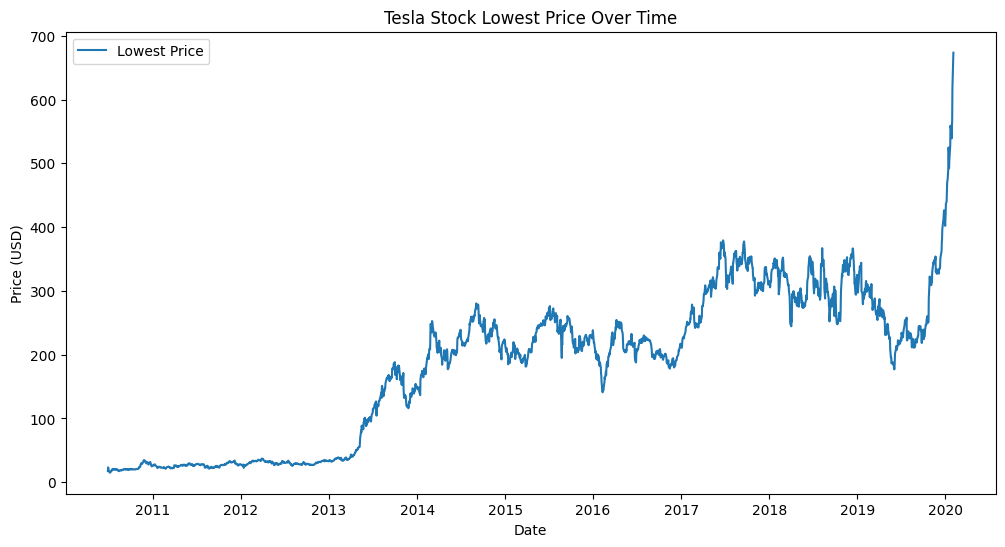

In [23]:
plt.figure(figsize=(12,6))
plt.plot(df['Low'], label='Lowest Price')
plt.title("Tesla Stock Lowest Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

<Axes: ylabel='Low'>

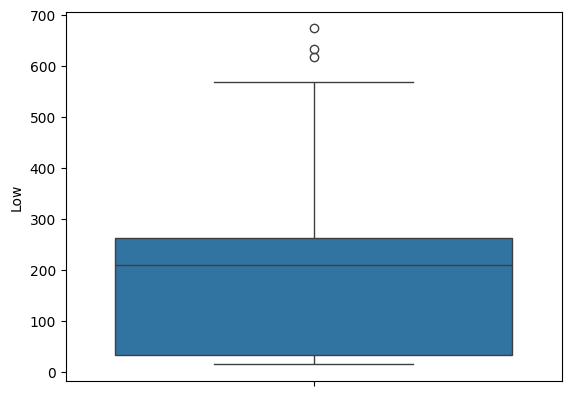

In [24]:
sns.boxplot(df['Low'])

(array([729., 142., 720., 520., 275.,  12.,   9.,   6.,   2.,   1.]),
 array([ 15.8 ,  92.22, 168.64, 245.06, 321.48, 397.9 , 474.32, 550.74,
        627.16, 703.58, 780.  ]),
 <BarContainer object of 10 artists>)

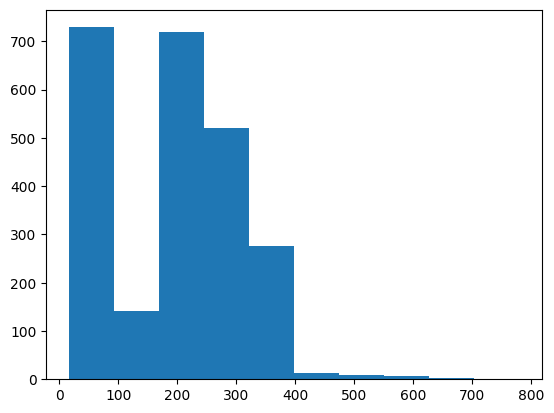

In [25]:
plt.hist(df['Close'])

/tmp/ipykernel_3103/3615683537.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Close'])


<Axes: xlabel='Close', ylabel='Density'>

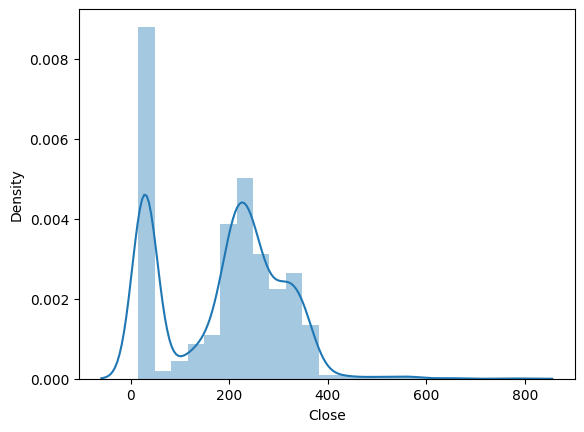

In [26]:
sns.distplot(df['Close'])

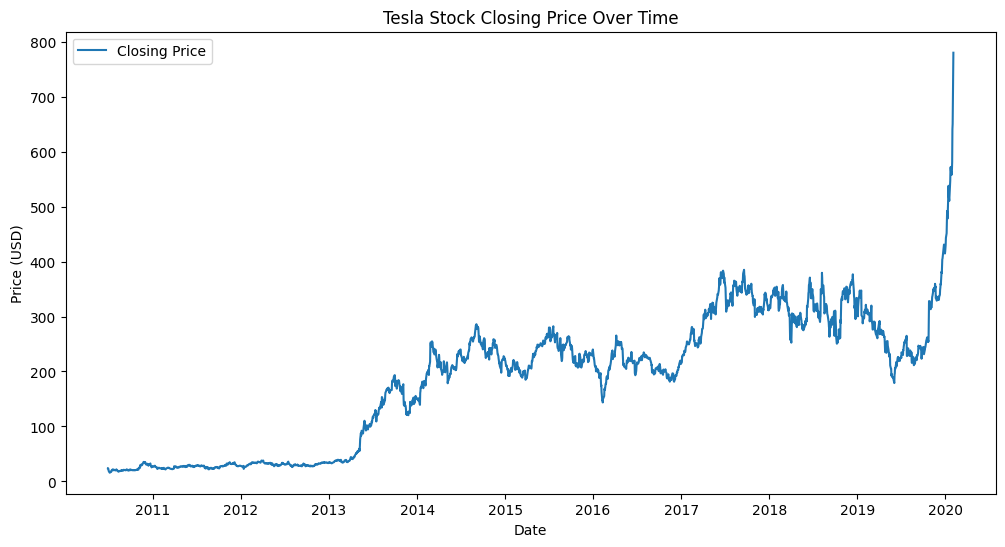

In [27]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Closing Price')
plt.title("Tesla Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


<Axes: ylabel='Close'>

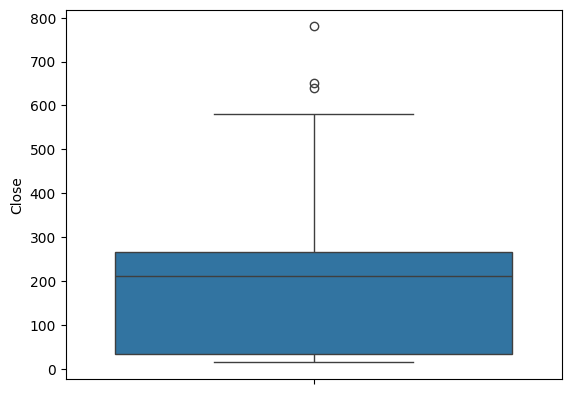

In [28]:
sns.boxplot(df['Close'])

(array([729., 142., 720., 520., 275.,  12.,   9.,   6.,   2.,   1.]),
 array([ 15.8 ,  92.22, 168.64, 245.06, 321.48, 397.9 , 474.32, 550.74,
        627.16, 703.58, 780.  ]),
 <BarContainer object of 10 artists>)

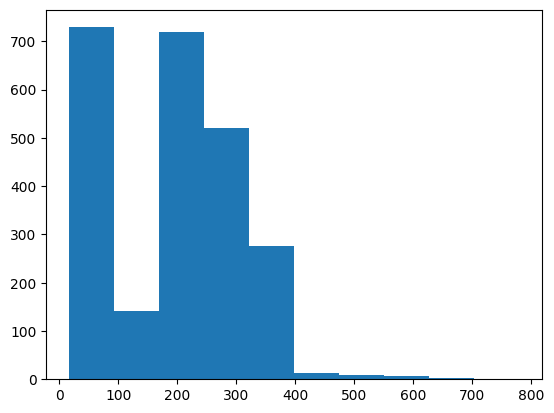

In [29]:
plt.hist(df['Adj Close'])

/tmp/ipykernel_3103/2174584222.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Adj Close'])


<Axes: xlabel='Adj Close', ylabel='Density'>

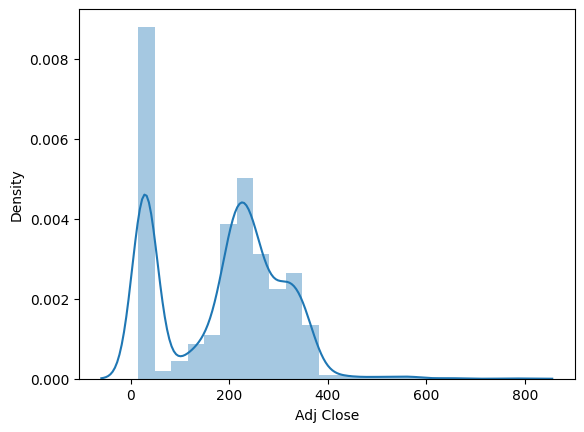

In [30]:
sns.distplot(df['Adj Close'])

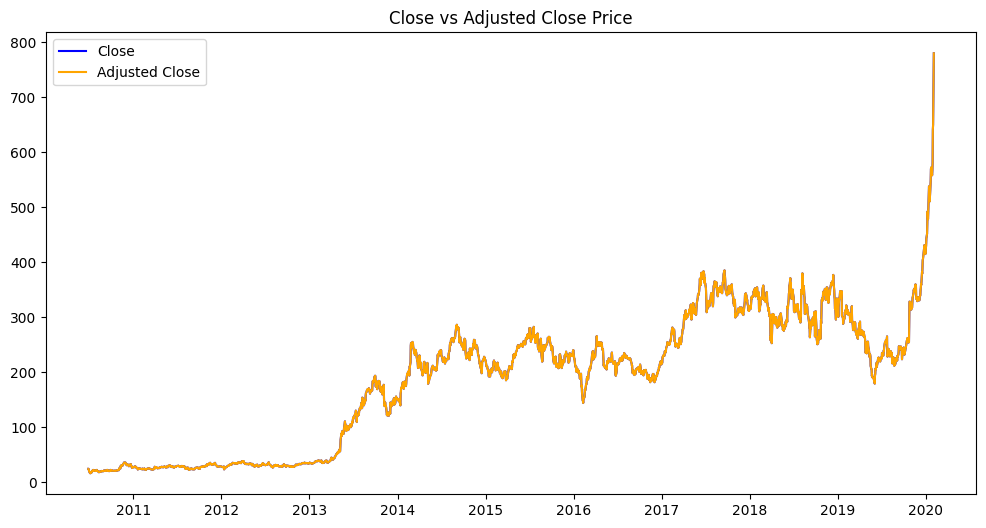

In [31]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close',color='blue')
plt.plot(df['Adj Close'], label='Adjusted Close',color='orange')
plt.legend()
plt.title("Close vs Adjusted Close Price")
plt.show()


<Axes: ylabel='Adj Close'>

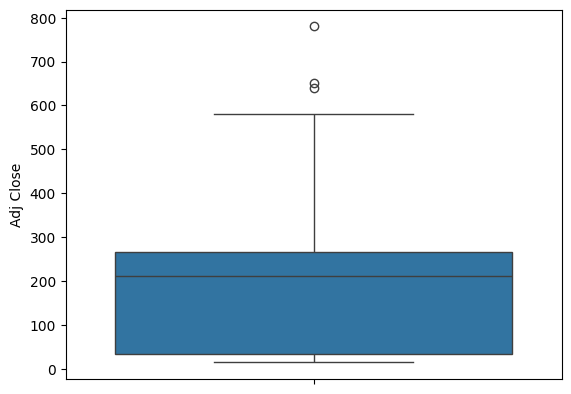

In [32]:
sns.boxplot(df['Adj Close'])

(array([1.269e+03, 8.040e+02, 2.100e+02, 6.700e+01, 3.400e+01, 1.700e+01,
        1.200e+01, 2.000e+00, 0.000e+00, 1.000e+00]),
 array([  118500.,  4813150.,  9507800., 14202450., 18897100., 23591750.,
        28286400., 32981050., 37675700., 42370350., 47065000.]),
 <BarContainer object of 10 artists>)

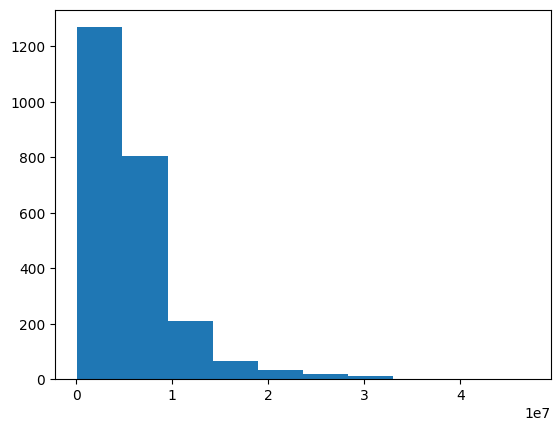

In [33]:
plt.hist(df['Volume'])

/tmp/ipykernel_3103/253520841.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Volume'])


<Axes: xlabel='Volume', ylabel='Density'>

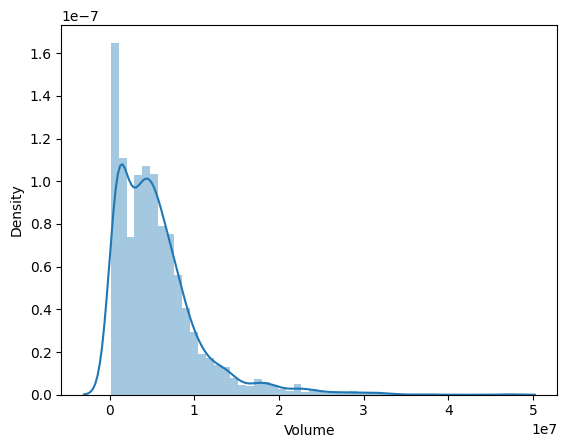

In [34]:
sns.distplot(df['Volume'])

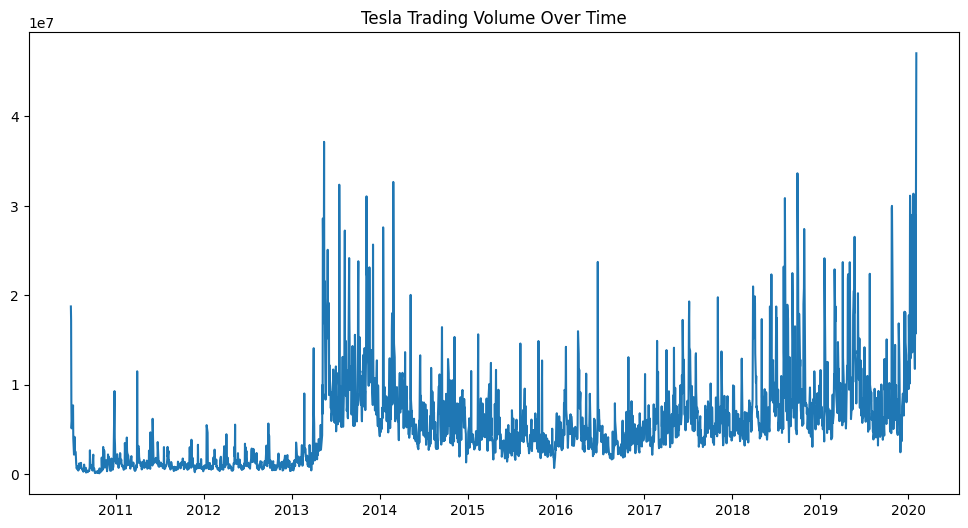

In [35]:
plt.figure(figsize=(12,6))
plt.plot(df['Volume'])
plt.title("Tesla Trading Volume Over Time")
plt.show()


<Axes: ylabel='Volume'>

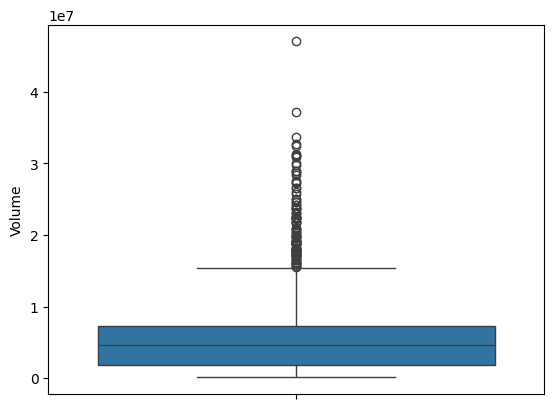

In [36]:
sns.boxplot(df['Volume'])

# **3.Feature Engineering**

In [37]:
data = df[['Adj Close']]                                         #Feature selection


In [38]:
data.head()

,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


In [39]:
from sklearn.preprocessing import MinMaxScaler                   #Scaling

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


In [40]:
scaled_data.shape

(2416, 1)

In [41]:
len(scaled_data)

2416

In [42]:
pd.DataFrame(scaled_data).head()

,0
0,0.010586
1,0.010508
2,0.008061
3,0.004449
4,0.000406


In [43]:
train_size = int(len(scaled_data) * 0.8)
print(train_size)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]


1932


In [135]:
train_series = scaler.inverse_transform(train_data).flatten()

In [136]:
test_series = scaler.inverse_transform(test_data).flatten()

In [44]:
train_data

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       ...,
       [0.43861553],
       [0.42823868],
       [0.41236586]])

In [45]:
len(train_data)

1932

In [46]:
train_data.shape

(1932, 1)

In [47]:
def create_sequences(data, window_size, forecast_horizon=1):
    X, y = [], []

    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + forecast_horizon - 1])

    return np.array(X), np.array(y)


In [48]:
WINDOW_SIZE = 60


In [49]:
X_train_1, y_train_1 = create_sequences(train_data, WINDOW_SIZE, forecast_horizon=1)
X_test_1, y_test_1 = create_sequences(test_data, WINDOW_SIZE, forecast_horizon=1)


In [50]:
X_train_1

array([[[1.05862327e-02],
        [1.05077205e-02],
        [8.06071578e-03],
        ...,
        [6.88301361e-03],
        [6.50353311e-03],
        [5.32583224e-03]],

       [[1.05077205e-02],
        [8.06071578e-03],
        [4.44909840e-03],
        ...,
        [6.50353311e-03],
        [5.32583224e-03],
        [4.92017666e-03]],

       [[8.06071578e-03],
        [4.44909840e-03],
        [4.05654279e-04],
        ...,
        [5.32583224e-03],
        [4.92017666e-03],
        [5.62679927e-03]],

       ...,

       [[3.81758714e-01],
        [3.83472921e-01],
        [3.80437057e-01],
        ...,
        [4.32308313e-01],
        [4.40002601e-01],
        [4.47029590e-01]],

       [[3.83472921e-01],
        [3.80437057e-01],
        [3.78696692e-01],
        ...,
        [4.40002601e-01],
        [4.47029590e-01],
        [4.38615533e-01]],

       [[3.80437057e-01],
        [3.78696692e-01],
        [3.76733855e-01],
        ...,
        [4.47029590e-01],
        [4.3861

In [51]:
X_train_1.shape                                         #1932-60=1872

(1872, 60, 1)

In [52]:
y_train_1

array([[0.00492018],
       [0.0056268 ],
       [0.00618948],
       ...,
       [0.43861553],
       [0.42823868],
       [0.41236586]])

In [53]:
y_train_1.shape

(1872, 1)

In [54]:
X_train_5, y_train_5 = create_sequences(train_data, WINDOW_SIZE, forecast_horizon=5)
X_test_5, y_test_5 = create_sequences(test_data, WINDOW_SIZE, forecast_horizon=5)


In [55]:
X_train_10, y_train_10 = create_sequences(train_data, WINDOW_SIZE, forecast_horizon=10)
X_test_10, y_test_10 = create_sequences(test_data, WINDOW_SIZE, forecast_horizon=10)


In [56]:
#Reshaping according to Rnn,LSTM
X_train_1 = X_train_1.reshape(X_train_1.shape[0], X_train_1.shape[1], 1)
X_test_1  = X_test_1.reshape(X_test_1.shape[0], X_test_1.shape[1], 1)


In [57]:
X_train_5 = X_train_5.reshape(X_train_5.shape[0], X_train_5.shape[1], 1)
X_test_5  = X_test_5.reshape(X_test_5.shape[0], X_test_5.shape[1], 1)


In [58]:
X_train_10 = X_train_10.reshape(X_train_10.shape[0], X_train_10.shape[1], 1)
X_test_10  = X_test_10.reshape(X_test_10.shape[0], X_test_10.shape[1], 1)


In [59]:
print(X_train_1.shape)
print(y_train_1.shape)


(1872, 60, 1)
(1872, 1)


## **4.Model Building**

## **4.1)RNN**

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error


In [61]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



In [62]:
# 1Day

In [63]:
rnn_1day = Sequential()

rnn_1day.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train_1.shape[1], 1)
))

rnn_1day.add(Dropout(0.2))
rnn_1day.add(Dense(1))

rnn_1day.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

rnn_1day.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history_rnn_1day = rnn_1day.fit(
    X_train_1, y_train_1,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0022 - val_loss: 4.7467e-04
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.6066e-04 - val_loss: 0.0012
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.4308e-04 - val_loss: 2.2116e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7281e-04 - val_loss: 1.9509e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6824e-04 - val_loss: 0.0010
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0967e-04 - val_loss: 8.6702e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.2524e-04 - val_loss: 5.7726e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.6470e-04 - val_loss: 8.9772e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.6194e-04 - val_loss: 2.8371e-04


In [65]:
rnn_1day_pred = rnn_1day.predict(X_test_1)

rnn_1day_pred_inv = scaler.inverse_transform(rnn_1day_pred)
y_test_1_inv = scaler.inverse_transform(y_test_1.reshape(-1,1))


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [66]:
rnn_1day_pred

array([[0.36070967],
       [0.3505335 ],
       [0.36084485],
       [0.36260137],
       [0.3640395 ],
       [0.37194768],
       [0.36947253],
       [0.38420182],
       [0.3784155 ],
       [0.40220785],
       [0.41132244],
       [0.4241294 ],
       [0.42918715],
       [0.44934058],
       [0.43897215],
       [0.46727014],
       [0.45459592],
       [0.46971586],
       [0.44392604],
       [0.43890068],
       [0.416217  ],
       [0.42427203],
       [0.4209005 ],
       [0.43200016],
       [0.4382703 ],
       [0.42555213],
       [0.42835623],
       [0.4092929 ],
       [0.39851803],
       [0.39948282],
       [0.39526182],
       [0.38670638],
       [0.40385354],
       [0.38753372],
       [0.4069052 ],
       [0.39201528],
       [0.40260407],
       [0.40418413],
       [0.40651506],
       [0.390415  ],
       [0.39764994],
       [0.37323168],
       [0.3825235 ],
       [0.36941308],
       [0.37213343],
       [0.3765311 ],
       [0.38392955],
       [0.398

In [67]:
rnn_1day_pred_inv

array([[291.4543 ],
       [283.67767],
       [291.55762],
       [292.89996],
       [293.999  ],
       [300.04242],
       [298.1509 ],
       [309.40704],
       [304.9851 ],
       [323.16724],
       [330.1326 ],
       [339.91968],
       [343.78482],
       [359.18607],
       [351.2625 ],
       [372.88785],
       [363.2022 ],
       [374.75687],
       [355.04828],
       [351.2079 ],
       [333.87302],
       [340.0287 ],
       [337.45215],
       [345.9345 ],
       [350.72617],
       [341.00693],
       [343.14984],
       [328.58163],
       [320.34747],
       [321.08478],
       [317.85907],
       [311.321  ],
       [324.42487],
       [311.95328],
       [326.75696],
       [315.37808],
       [323.47003],
       [324.67752],
       [326.4588 ],
       [314.15515],
       [319.68408],
       [301.02365],
       [308.12445],
       [298.10547],
       [300.18436],
       [303.54507],
       [309.19897],
       [320.3716 ],
       [338.6856 ],
       [344.13504],


In [68]:
rnn_1day_mse = mean_squared_error(y_test_1_inv, rnn_1day_pred_inv)
print("SimpleRNN 1-Day MSE:", rnn_1day_mse)


SimpleRNN 1-Day MSE: 384.6392759976362


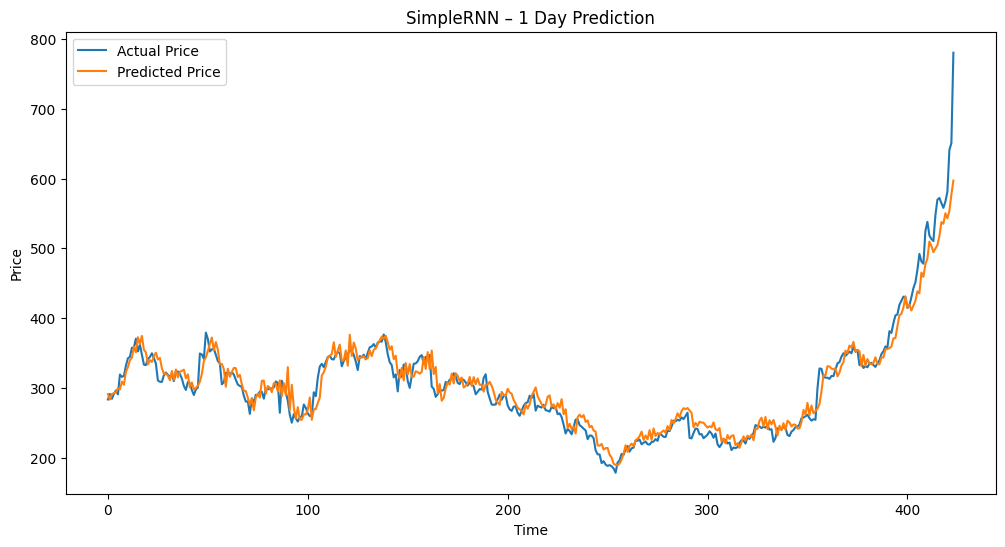

In [69]:
plt.figure(figsize=(12,6))
plt.plot(y_test_1_inv, label='Actual Price')
plt.plot(rnn_1day_pred_inv, label='Predicted Price')
plt.title("SimpleRNN – 1 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [70]:
#5 Day

In [71]:
rnn_5day = Sequential()

rnn_5day.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train_5.shape[1], 1)
))

rnn_5day.add(Dropout(0.2))
rnn_5day.add(Dense(1))

rnn_5day.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

rnn_5day.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
history_rnn_5day = rnn_5day.fit(
    X_train_5, y_train_5,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0113 - val_loss: 0.0028
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0027
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0022
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.1527e-04 - val_loss: 0.0012


In [73]:
rnn_5day_pred = rnn_5day.predict(X_test_5)

rnn_5day_pred_inv = scaler.inverse_transform(rnn_5day_pred)
y_test_5_inv = scaler.inverse_transform(y_test_5.reshape(-1,1))


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [74]:
rnn_5day_pred

array([[0.35106876],
       [0.36370987],
       [0.3617889 ],
       [0.35057312],
       [0.35379684],
       [0.3618003 ],
       [0.36080617],
       [0.35878274],
       [0.36366263],
       [0.36956507],
       [0.3791231 ],
       [0.36680984],
       [0.37224624],
       [0.37697643],
       [0.3625989 ],
       [0.3933289 ],
       [0.3942288 ],
       [0.37178552],
       [0.3948859 ],
       [0.40296406],
       [0.37852544],
       [0.3840123 ],
       [0.39318258],
       [0.42057797],
       [0.3893658 ],
       [0.38621446],
       [0.37949258],
       [0.38115862],
       [0.38096872],
       [0.38237774],
       [0.39214715],
       [0.36248946],
       [0.3453037 ],
       [0.35827115],
       [0.33331808],
       [0.34509262],
       [0.3571034 ],
       [0.3508776 ],
       [0.36540627],
       [0.34266093],
       [0.36371085],
       [0.36413476],
       [0.3362369 ],
       [0.3638265 ],
       [0.36189836],
       [0.3391003 ],
       [0.33408183],
       [0.344

In [75]:
rnn_5day_pred_inv

array([[284.08676],
       [293.74707],
       [292.27908],
       [283.70798],
       [286.17154],
       [292.2878 ],
       [291.52808],
       [289.98178],
       [293.71097],
       [298.22162],
       [305.52588],
       [296.1161 ],
       [300.27057],
       [303.88538],
       [292.89807],
       [316.38196],
       [317.06964],
       [299.9185 ],
       [317.5718 ],
       [323.74512],
       [305.06912],
       [309.2622 ],
       [316.2701 ],
       [337.2057 ],
       [313.35333],
       [310.9451 ],
       [305.80823],
       [307.08142],
       [306.93628],
       [308.01306],
       [315.47885],
       [292.81445],
       [279.6811 ],
       [289.59082],
       [270.52167],
       [279.51978],
       [288.69843],
       [283.94067],
       [295.0435 ],
       [277.66147],
       [293.74783],
       [294.07178],
       [272.75223],
       [293.8362 ],
       [292.36273],
       [274.94046],
       [271.10532],
       [279.32898],
       [283.1208 ],
       [299.7655 ],


In [76]:
rnn_5day_mse = mean_squared_error(y_test_5_inv, rnn_5day_pred_inv)
print("SimpleRNN 5-Day MSE:", rnn_5day_mse)


SimpleRNN 5-Day MSE: 3684.7216292255234


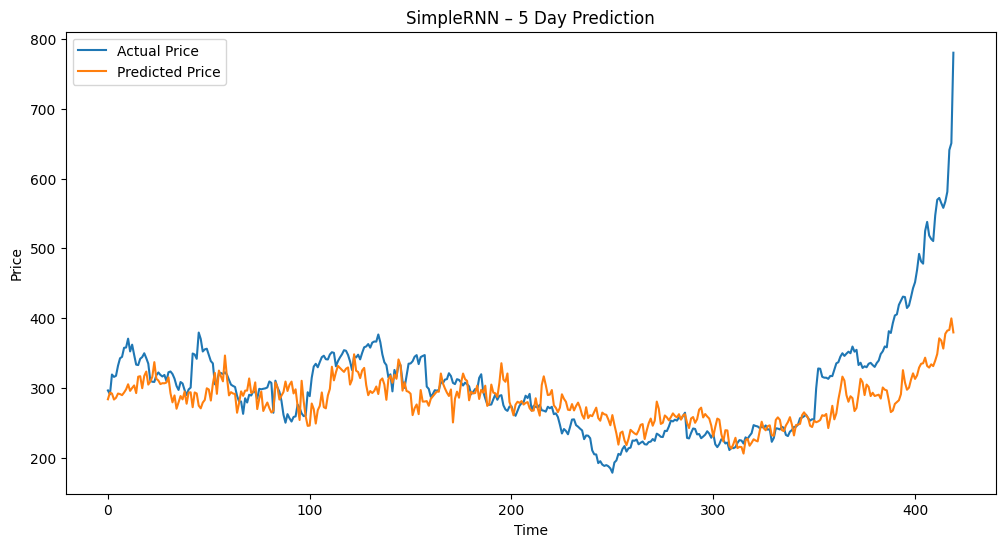

In [77]:
plt.figure(figsize=(12,6))
plt.plot(y_test_5_inv, label='Actual Price')
plt.plot(rnn_5day_pred_inv, label='Predicted Price')
plt.title("SimpleRNN – 5 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [78]:
#10 Days

In [79]:
rnn_10day = Sequential()

rnn_10day.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train_10.shape[1], 1)
))

rnn_10day.add(Dropout(0.2))
rnn_10day.add(Dense(1))

rnn_10day.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

rnn_10day.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history_rnn_10day = rnn_10day.fit(
    X_train_10, y_train_10,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0059 - val_loss: 0.0093
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 0.0043
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0038
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 0.0019
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.9873e-04 - val_loss: 0.0026


In [81]:
rnn_10day_pred = rnn_10day.predict(X_test_10)

rnn_10day_pred_inv = scaler.inverse_transform(rnn_10day_pred)
y_test_10_inv = scaler.inverse_transform(y_test_10.reshape(-1,1))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [82]:
rnn_10day_pred

array([[0.3078475 ],
       [0.29754   ],
       [0.30221522],
       [0.3127095 ],
       [0.31417277],
       [0.3088397 ],
       [0.33321017],
       [0.31314272],
       [0.3294615 ],
       [0.34056967],
       [0.3261085 ],
       [0.32672763],
       [0.3214446 ],
       [0.32523996],
       [0.33858833],
       [0.32827607],
       [0.33539212],
       [0.34135675],
       [0.31117034],
       [0.34739906],
       [0.347128  ],
       [0.34776625],
       [0.35123008],
       [0.3559575 ],
       [0.34757432],
       [0.36929044],
       [0.35080224],
       [0.3606332 ],
       [0.35399574],
       [0.3368938 ],
       [0.33412993],
       [0.33697203],
       [0.31623837],
       [0.32630718],
       [0.31482437],
       [0.30349034],
       [0.3179504 ],
       [0.3074635 ],
       [0.31292903],
       [0.3250516 ],
       [0.30933464],
       [0.32573113],
       [0.31972662],
       [0.31297603],
       [0.3121108 ],
       [0.30257323],
       [0.3014063 ],
       [0.307

In [83]:
rnn_10day_pred_inv

array([[251.05705],
       [243.18007],
       [246.75287],
       [254.7726 ],
       [255.89084],
       [251.8153 ],
       [270.4392 ],
       [255.10367],
       [267.57446],
       [276.06335],
       [265.01212],
       [265.48526],
       [261.44797],
       [264.34836],
       [274.5492 ],
       [266.66858],
       [272.10666],
       [276.66483],
       [253.59637],
       [281.28235],
       [281.07523],
       [281.56296],
       [284.21002],
       [287.82272],
       [281.4163 ],
       [298.01175],
       [283.88306],
       [291.39587],
       [286.32355],
       [273.25424],
       [271.1421 ],
       [273.31403],
       [257.46936],
       [265.16394],
       [256.3888 ],
       [247.72731],
       [258.77768],
       [250.7636 ],
       [254.94037],
       [264.20444],
       [252.19353],
       [264.72372],
       [260.13507],
       [254.97629],
       [254.31508],
       [247.02646],
       [246.13469],
       [250.79141],
       [252.19229],
       [274.56696],


In [84]:
rnn_10day_mse = mean_squared_error(y_test_10_inv, rnn_10day_pred_inv)
print("SimpleRNN 10-Day MSE:", rnn_10day_mse)


SimpleRNN 10-Day MSE: 6839.489168604457


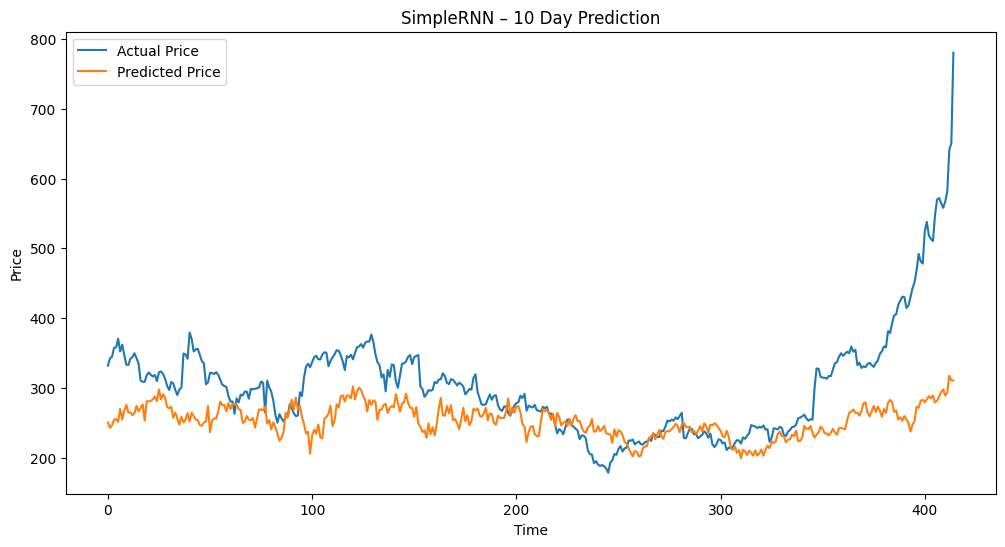

In [85]:
plt.figure(figsize=(12,6))
plt.plot(y_test_10_inv, label='Actual Price')
plt.plot(rnn_10day_pred_inv, label='Predicted Price')
plt.title("SimpleRNN – 10 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


## **4.2)LSTM**

In [86]:
#1 Day

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [88]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [89]:
lstm_1day = Sequential()

lstm_1day.add(LSTM(
    units=50,
    activation='tanh',
    input_shape=(X_train_1.shape[1], 1)
))

lstm_1day.add(Dropout(0.2))
lstm_1day.add(Dense(1))

lstm_1day.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_1day.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
history_lstm_1day = lstm_1day.fit(
    X_train_1, y_train_1,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0056 - val_loss: 0.0013
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 6.7290e-04 - val_loss: 5.3231e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 5.6362e-04 - val_loss: 5.3701e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 4.8839e-04 - val_loss: 5.5892e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.6059e-04 - val_loss: 4.3023e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.2646e-04 - val_loss: 4.2476e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.1687e-04 - val_loss: 3.9538e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.8103e-04 - val_loss: 4.1280e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.6463e-04 - val_loss: 9.8710e-04
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.6946e-04 - val_loss: 4.3158e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.8422e-04 - val_

In [91]:
lstm_1day_pred = lstm_1day.predict(X_test_1)

lstm_1day_pred_inv = scaler.inverse_transform(lstm_1day_pred)
y_test_1_inv = scaler.inverse_transform(y_test_1.reshape(-1,1))


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [92]:
lstm_1day_mse = mean_squared_error(y_test_1_inv, lstm_1day_pred_inv)
print("LSTM 1-Day MSE:", lstm_1day_mse)


LSTM 1-Day MSE: 394.67015631484674


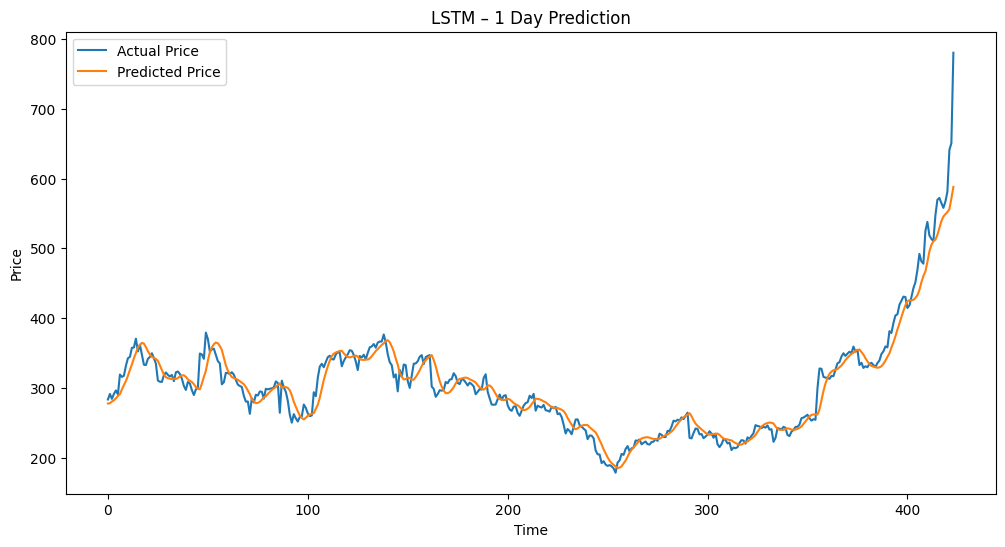

In [93]:
plt.figure(figsize=(12,6))
plt.plot(y_test_1_inv, label='Actual Price')
plt.plot(lstm_1day_pred_inv, label='Predicted Price')
plt.title("LSTM – 1 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [94]:
#5 Day

In [95]:
lstm_5day = Sequential()

lstm_5day.add(LSTM(
    units=50,
    activation='tanh',
    input_shape=(X_train_5.shape[1], 1)
))

lstm_5day.add(Dropout(0.2))
lstm_5day.add(Dense(1))

lstm_5day.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_5day.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
history_lstm_5day = lstm_5day.fit(
    X_train_5, y_train_5,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0091 - val_loss: 0.0011
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.8051e-04 - val_loss: 8.8232e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.1062e-04 - val_loss: 8.5890e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.6224e-04 - val_loss: 8.3948e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.9494e-04 - val_loss: 0.0010


In [97]:
lstm_5day_pred = lstm_5day.predict(X_test_5)

lstm_5day_pred_inv = scaler.inverse_transform(lstm_5day_pred)
y_test_5_inv = scaler.inverse_transform(y_test_5.reshape(-1,1))


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [98]:
lstm_5day_mse = mean_squared_error(y_test_5_inv, lstm_5day_pred_inv)
print("LSTM 5-Day MSE:", lstm_5day_mse)


LSTM 5-Day MSE: 1219.7699955245473


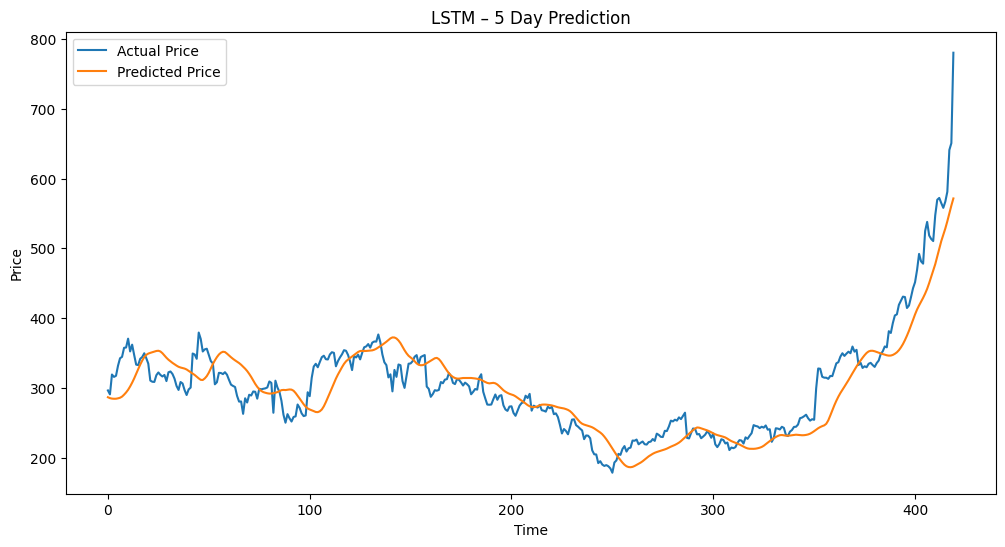

In [99]:
plt.figure(figsize=(12,6))
plt.plot(y_test_5_inv, label='Actual Price')
plt.plot(lstm_5day_pred_inv, label='Predicted Price')
plt.title("LSTM – 5 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


In [100]:
#10 Days

In [101]:
lstm_10day = Sequential()

lstm_10day.add(LSTM(
    units=50,
    activation='tanh',
    input_shape=(X_train_10.shape[1], 1)
))

lstm_10day.add(Dropout(0.2))
lstm_10day.add(Dense(1))

lstm_10day.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_10day.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
history_lstm_10day = lstm_10day.fit(
    X_train_10, y_train_10,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0084 - val_loss: 0.0012
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 8.4844e-04 - val_loss: 0.0014
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 9.3618e-04 - val_loss: 0.0011
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.0113e-04 - val_loss: 0.0012


In [103]:
lstm_10day_pred = lstm_10day.predict(X_test_10)

lstm_10day_pred_inv = scaler.inverse_transform(lstm_10day_pred)
y_test_10_inv = scaler.inverse_transform(y_test_10.reshape(-1,1))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [104]:
lstm_10day_mse = mean_squared_error(y_test_10_inv, lstm_10day_pred_inv)
print("LSTM 10-Day MSE:", lstm_10day_mse)


LSTM 10-Day MSE: 1971.5216196193896


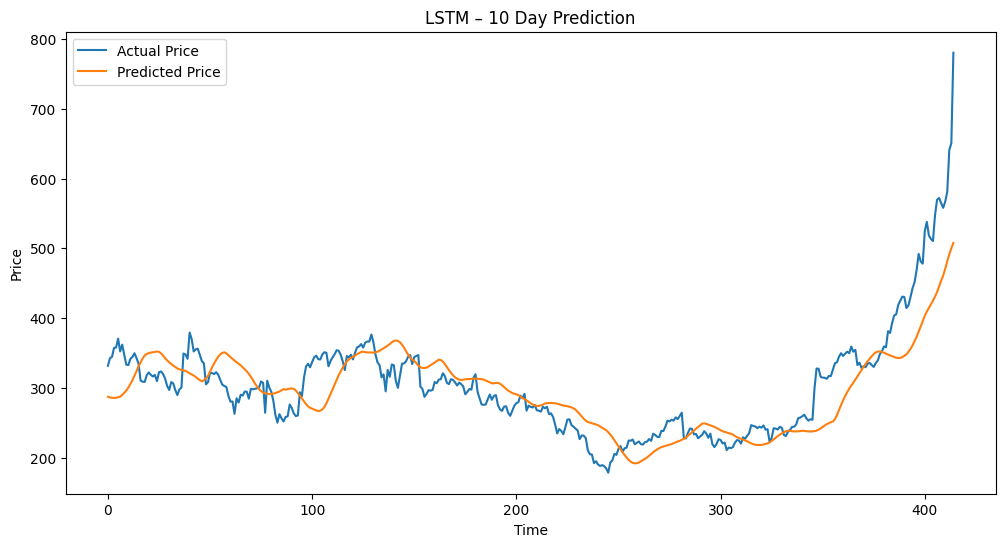

In [105]:
plt.figure(figsize=(12,6))
plt.plot(y_test_10_inv, label='Actual Price')
plt.plot(lstm_10day_pred_inv, label='Predicted Price')
plt.title("LSTM – 10 Day Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


## **4.3)Arima**

In [114]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.9 MB/s eta 0:00:00


In [137]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

from pmdarima import auto_arima

In [138]:
print("Finding Best ARIMA Parameters...")

auto_model = auto_arima(
    train_series,
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Finding Best ARIMA Parameters...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11621.702, Time=4.19 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11629.384, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11629.052, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11629.070, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11629.408, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=11633.069, Time=0.74 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=11630.894, Time=3.06 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=11633.837, Time=1.52 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=11633.838, Time=2.38 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=11631.050, Time=0.72 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=11631.844, Time=1.03 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=11631.847, Time=1.27 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=11635.833, Time=0.76 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=11620.864, 

In [139]:
final_arima = ARIMA(train_series, order=(2,1,2))

final_arima_fit = final_arima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [140]:
arima_1day_forecast = final_arima_fit.forecast(steps=1)

print(" ARIMA 1-DAY FORECAST ")

print(arima_1day_forecast)

 ARIMA 1-DAY FORECAST 
[331.68434613]


In [141]:
arima_5day_forecast = final_arima_fit.forecast(steps=5)

print(" ARIMA 5-DAY FORECAST ")

print(arima_5day_forecast)

 ARIMA 5-DAY FORECAST 
[331.68434613 333.05797541 333.69533232 332.99156455 331.66529699]


In [142]:
arima_10day_forecast = final_arima_fit.forecast(steps=10)

print(" ARIMA 10-DAY FORECAST ")

print(arima_10day_forecast)

 ARIMA 10-DAY FORECAST 
[331.68434613 333.05797541 333.69533232 332.99156455 331.66529699
 331.02591884 331.68141897 332.96138167 333.60157504 332.99210428]


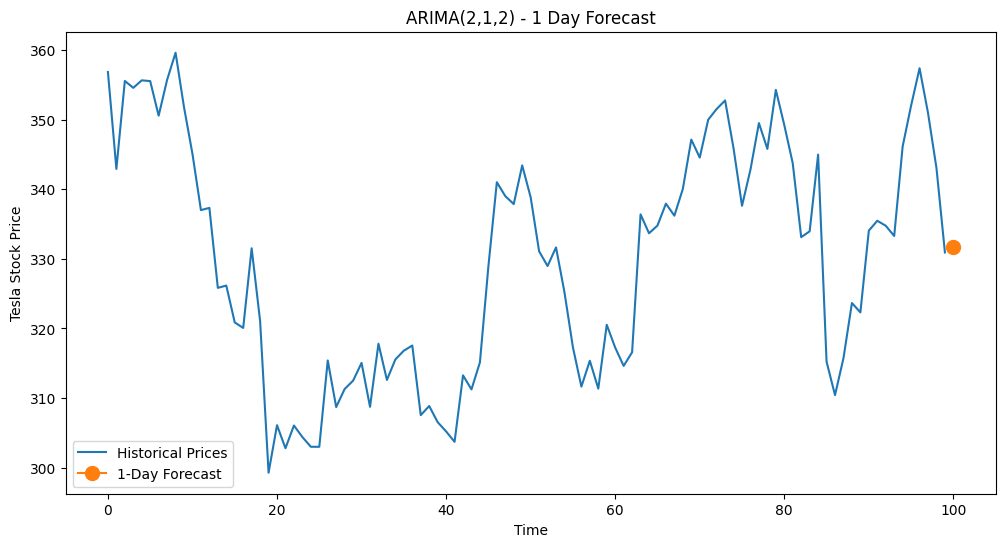

In [143]:
plt.figure(figsize=(12,6))

# Last 100 historical points
plt.plot(train_series[-100:], label='Historical Prices')

# Plot 1-day prediction
future_index_1 = [len(train_series[-100:])]

plt.plot(
    future_index_1,
    arima_1day_forecast,
    marker='o',
    markersize=10,
    label='1-Day Forecast'
)

plt.title("ARIMA(2,1,2) - 1 Day Forecast")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

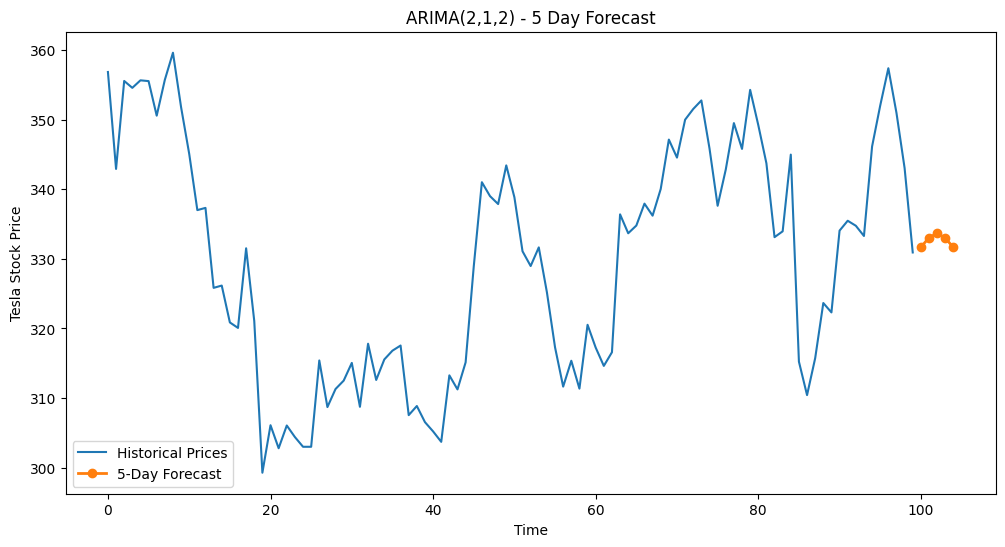

In [144]:
plt.figure(figsize=(12,6))

# Historical data
plt.plot(train_series[-100:], label='Historical Prices')

# Future forecast index
future_index_5 = range(
    len(train_series[-100:]),
    len(train_series[-100:]) + 5
)

# Plot forecast
plt.plot(
    future_index_5,
    arima_5day_forecast,
    marker='o',
    linewidth=2,
    label='5-Day Forecast'
)

plt.title("ARIMA(2,1,2) - 5 Day Forecast")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

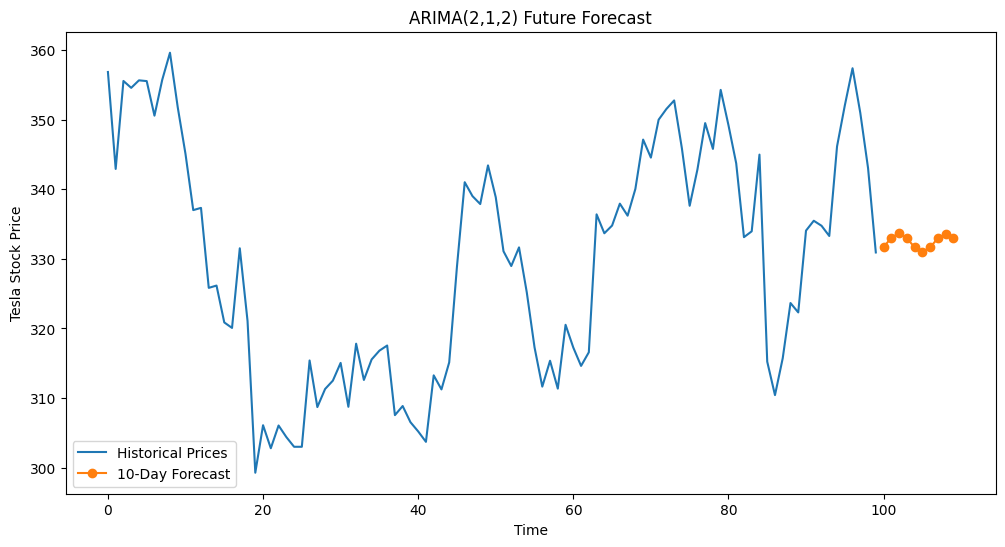

In [145]:
plt.figure(figsize=(12,6))

# Plot historical data
plt.plot(train_series[-100:], label='Historical Prices')

# Forecast future values
future_index = range(
    len(train_series[-100:]),
    len(train_series[-100:]) + 10
)

plt.plot(
    future_index,
    arima_10day_forecast,
    marker='o',
    label='10-Day Forecast'
)

plt.title("ARIMA(2,1,2) Future Forecast")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

In [157]:
from sklearn.metrics import mean_squared_error
import numpy as np

arima_pred = final_arima_fit.forecast(
    steps=len(test_series)
)

arima_mse = mean_squared_error(
    test_series,
    arima_pred
)

arima_rmse = np.sqrt(arima_mse)

print("ARIMA MSE:", arima_mse)

print("ARIMA RMSE:", arima_rmse)

ARIMA MSE: 6021.913217793229
ARIMA RMSE: 77.60098722176947


## **4.4)Holt-Winters**

In [146]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [147]:
hw_model = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal=None
)

# Train model
hw_fit = hw_model.fit()

In [148]:
hw_1day_forecast = hw_fit.forecast(steps=1)

print(" HOLT-WINTERS 1-DAY FORECAST ")

print(hw_1day_forecast)

 HOLT-WINTERS 1-DAY FORECAST 
[331.08918209]


In [149]:
hw_5day_forecast = hw_fit.forecast(steps=5)

print("HOLT-WINTERS 5-DAY FORECAST ")

print(hw_5day_forecast)

HOLT-WINTERS 5-DAY FORECAST 
[331.08918209 331.24837101 331.40755992 331.56674883 331.72593774]


In [150]:
hw_10day_forecast = hw_fit.forecast(steps=10)

print(" HOLT-WINTERS 10-DAY FORECAST")

print(hw_10day_forecast)

 HOLT-WINTERS 10-DAY FORECAST
[331.08918209 331.24837101 331.40755992 331.56674883 331.72593774
 331.88512665 332.04431556 332.20350447 332.36269338 332.52188229]


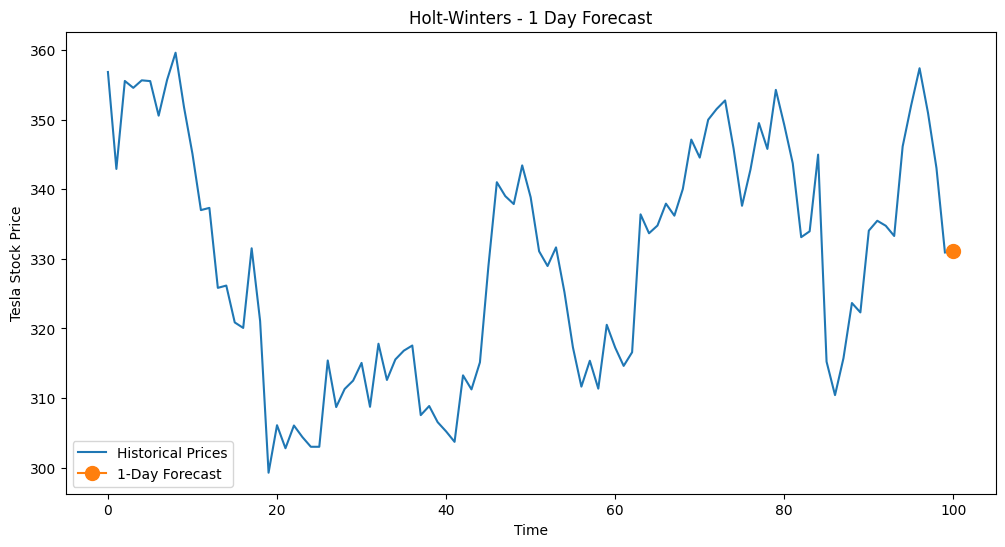

In [151]:
plt.figure(figsize=(12,6))

# Historical data
plt.plot(train_series[-100:], label='Historical Prices')

# Forecast
future_index_1 = [len(train_series[-100:])]

plt.plot(
    future_index_1,
    hw_1day_forecast,
    marker='o',
    markersize=10,
    label='1-Day Forecast'
)

plt.title("Holt-Winters - 1 Day Forecast")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

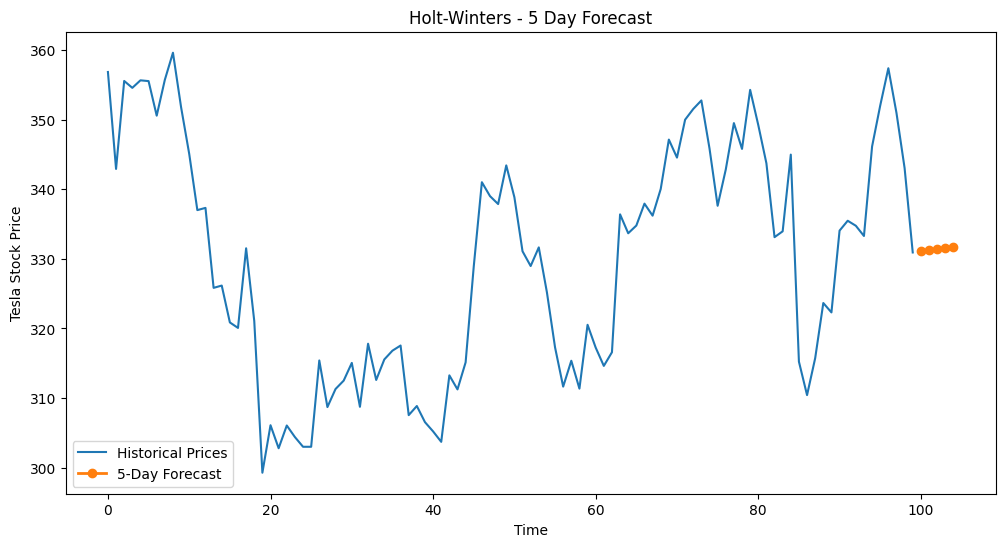

In [152]:
plt.figure(figsize=(12,6))

plt.plot(train_series[-100:], label='Historical Prices')

future_index_5 = range(
    len(train_series[-100:]),
    len(train_series[-100:]) + 5
)

plt.plot(
    future_index_5,
    hw_5day_forecast,
    marker='o',
    linewidth=2,
    label='5-Day Forecast'
)

plt.title("Holt-Winters - 5 Day Forecast")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

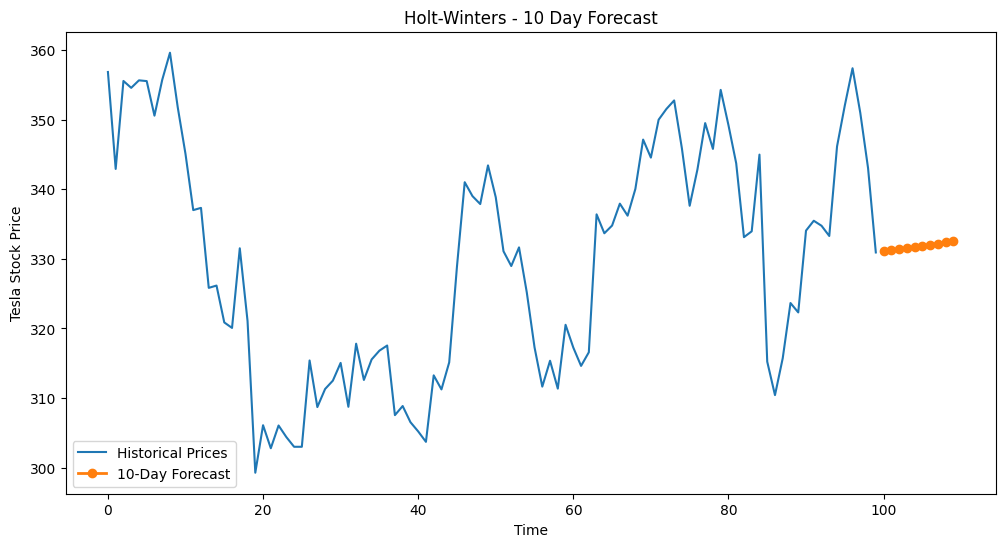

In [153]:
plt.figure(figsize=(12,6))

plt.plot(train_series[-100:], label='Historical Prices')

future_index_10 = range(
    len(train_series[-100:]),
    len(train_series[-100:]) + 10
)

plt.plot(
    future_index_10,
    hw_10day_forecast,
    marker='o',
    linewidth=2,
    label='10-Day Forecast'
)

plt.title("Holt-Winters - 10 Day Forecast")

plt.xlabel("Time")

plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

In [154]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict test set
hw_test_pred = hw_fit.forecast(len(test_series))

# Metrics
hw_mse = mean_squared_error(test_series, hw_test_pred)

hw_rmse = np.sqrt(hw_mse)

print("Holt-Winters MSE:", hw_mse)

print("Holt-Winters RMSE:", hw_rmse)

Holt-Winters MSE: 9760.432967862049
Holt-Winters RMSE: 98.79490355206613


In [158]:
import pandas as pd
import numpy as np

# =====================================================
# CREATE COMPARISON TABLE
# =====================================================

comparison_df = pd.DataFrame({

    'Model': [
        'SimpleRNN (1-Day)',
        'SimpleRNN (5-Day)',
        'SimpleRNN (10-Day)',
        'LSTM (1-Day)',
        'LSTM (5-Day)',
        'LSTM (10-Day)',
        'ARIMA (2,1,2)',
        'Holt-Winters'
    ],

    'MSE': [
        rnn_1day_mse,
        rnn_5day_mse,
        rnn_10day_mse,
        lstm_1day_mse,
        lstm_5day_mse,
        lstm_10day_mse,
        arima_mse,
        hw_mse
    ]
})

# =====================================================
# CALCULATE RMSE
# =====================================================

comparison_df['RMSE'] = np.sqrt(comparison_df['MSE'])

# =====================================================
# SORT MODELS BY PERFORMANCE
# =====================================================

comparison_df = comparison_df.sort_values(
    by='RMSE'
)

# =====================================================
# DISPLAY RESULTS
# =====================================================

print("========== MODEL COMPARISON ==========\n")

print(comparison_df)

========== MODEL COMPARISON ==========

                Model          MSE       RMSE
0   SimpleRNN (1-Day)   384.639276  19.612223
3        LSTM (1-Day)   394.670156  19.866307
4        LSTM (5-Day)  1219.769996  34.925206
5       LSTM (10-Day)  1971.521620  44.401820
1   SimpleRNN (5-Day)  3684.721629  60.701908
6       ARIMA (2,1,2)  6021.913218  77.600987
2  SimpleRNN (10-Day)  6839.489169  82.701204
7        Holt-Winters  9760.432968  98.794904


In [ ]:
import os
os.makedirs("models", exist_ok=True)


In [ ]:
rnn_1day.save("models/rnn_1day.h5")
rnn_5day.save("models/rnn_5day.h5")
rnn_10day.save("models/rnn_10day.h5")


In [ ]:
lstm_1day.save("models/lstm_1day.h5")
lstm_5day.save("models/lstm_5day.h5")
lstm_10day.save("models/lstm_10day.h5")


In [ ]:
import joblib
joblib.dump(scaler, "models/minmax_scaler.pkl")

['models/minmax_scaler.pkl']

In [159]:
comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

In [160]:
df.to_csv("cleaned_tesla_stock.csv", index=False)

In [161]:
arima_forecast_df = pd.DataFrame({

    'ARIMA_1Day': pd.Series(arima_1day_forecast),

    'ARIMA_5Day': pd.Series(arima_5day_forecast),

    'ARIMA_10Day': pd.Series(arima_10day_forecast)

})

arima_forecast_df.to_csv(
    "arima_forecasts.csv",
    index=False
)

In [162]:
hw_forecast_df = pd.DataFrame({

    'HW_1Day': pd.Series(hw_1day_forecast),

    'HW_5Day': pd.Series(hw_5day_forecast),

    'HW_10Day': pd.Series(hw_10day_forecast)

})

hw_forecast_df.to_csv(
    "holt_winters_forecasts.csv",
    index=False
)

In [163]:
rnn_df = pd.DataFrame({

    'Actual_1Day': y_test_1_inv.flatten(),
    'RNN_1Day_Pred': rnn_1day_pred_inv.flatten()

})

rnn_df.to_csv(
    "rnn_predictions.csv",
    index=False
)

In [164]:
lstm_df = pd.DataFrame({

    'Actual_1Day': y_test_1_inv.flatten(),
    'LSTM_1Day_Pred': lstm_1day_pred_inv.flatten()

})

lstm_df.to_csv(
    "lstm_predictions.csv",
    index=False
)

In [165]:
combined_df = pd.DataFrame({

    'Actual': y_test_1_inv.flatten(),

    'RNN_Predicted': rnn_1day_pred_inv.flatten(),

    'LSTM_Predicted': lstm_1day_pred_inv.flatten(),

    'ARIMA_Predicted': arima_pred[:len(y_test_1_inv)],

    'HW_Predicted': hw_test_pred[:len(y_test_1_inv)]

})

combined_df.to_csv(
    "actual_vs_predicted.csv",
    index=False
)

In [166]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [167]:
df.to_csv(
    "cleaned_tesla_stock.csv",
    index=False
)

In [168]:
df_reset = df.reset_index()

In [169]:
df_reset.to_csv(
    "cleaned_tesla_stock.csv",
    index=False
)